In [15]:
import sys
sys.path.append('../')
print("System path updated.")

System path updated.


# Exploratory Data Analysis (EDA)

This notebook explores the Jigsaw Toxic Comment dataset to understand:
- class distribution
- label relationships
- text characteristics
- modeling implications

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set(style="whitegrid")

In [20]:
from src.data.load_data import load_train_data

df = load_train_data()

print("Shape:", df.shape)
df.head()

Shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [21]:
LABELS = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

In [22]:
df[LABELS].head()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [23]:
df[LABELS].sum() # the data is very imbalanced

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

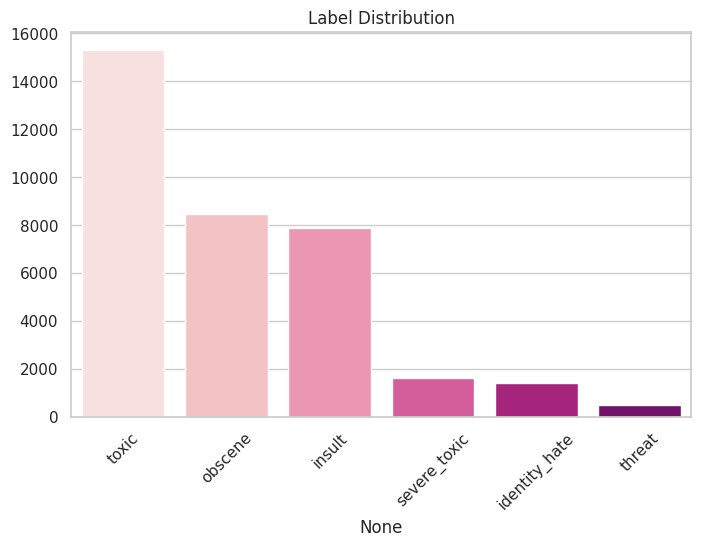

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = df[LABELS].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette="RdPu", legend=False)
plt.title("Label Distribution")
plt.xticks(rotation=45)
plt.show()

In [25]:
df['num_labels'] = df[LABELS].sum(axis=1)

df['num_labels'].value_counts().sort_index()

# the chart below means that 6360 have one label, 31 have all labels, etc

num_labels
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64

In [26]:
print("Missing values per column:\n", df.isnull().sum())

duplicate_comments = df['comment_text'].duplicated().sum()
print(f"\nNumber of duplicate comments: {duplicate_comments}")

if duplicate_comments > 0:
    print("\nSample of duplicate comments (first 5):")
    print(df[df['comment_text'].duplicated(keep=False)].sort_values(by='comment_text')['comment_text'].head())

# a clean data with no missing values and dublicates

Missing values per column:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
num_labels       0
dtype: int64

Number of duplicate comments: 0


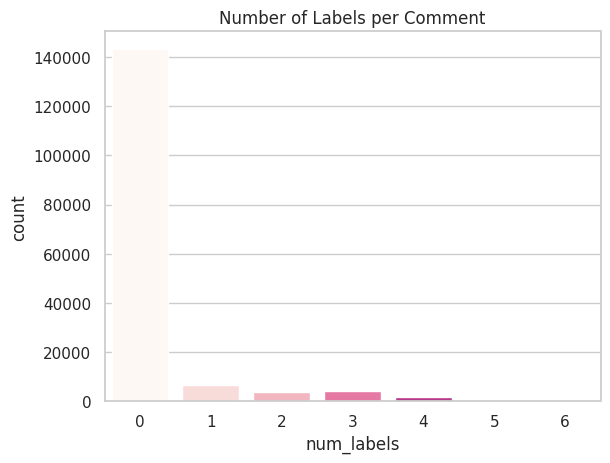

In [27]:
sns.countplot(x='num_labels', data=df, hue='num_labels', palette="RdPu", legend=False)
plt.title("Number of Labels per Comment")
plt.show()

In [28]:
df['is_toxic'] = (df[LABELS].sum(axis=1) > 0).astype(int)

df['is_toxic'].value_counts()

is_toxic
0    143346
1     16225
Name: count, dtype: int64

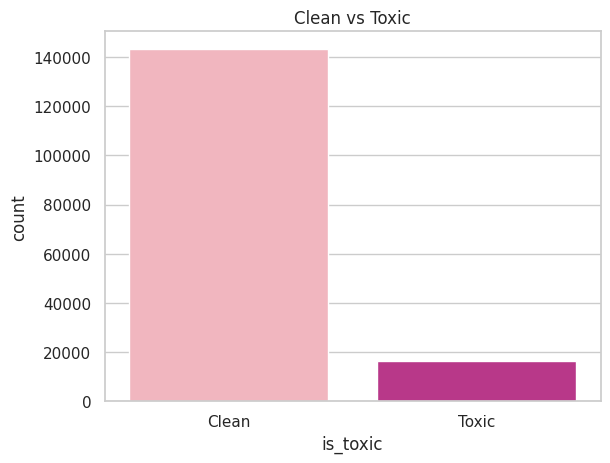

In [29]:
sns.countplot(x='is_toxic', data=df, hue='is_toxic', palette="RdPu", legend=False)
plt.xticks([0,1], ['Clean','Toxic'])
plt.title("Clean vs Toxic")
plt.show()

In [30]:
df['comment_length'] = df['comment_text'].astype(str).apply(len)

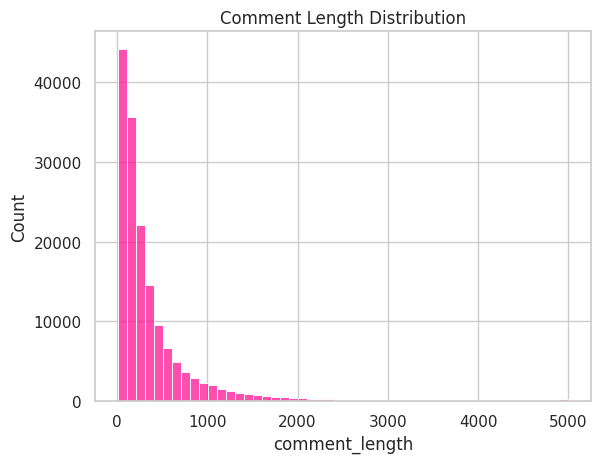

In [31]:
sns.histplot(df['comment_length'], bins=50, color='deeppink')
plt.title("Comment Length Distribution")
plt.show()
# Most comments are short, with only a few very long comments, resulting in a
# highly right-skewed length distribution.

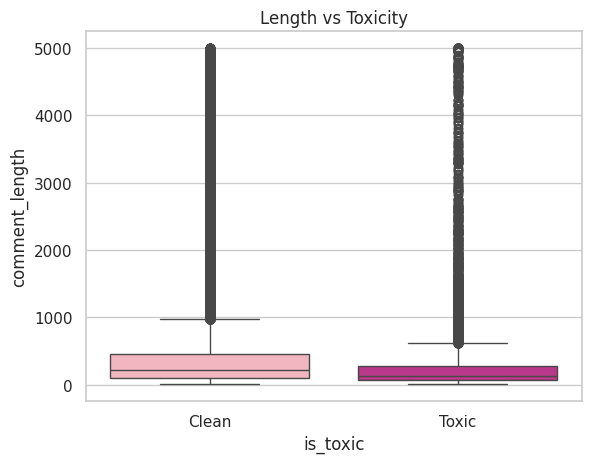

In [32]:
sns.boxplot(x='is_toxic', y='comment_length', data=df, hue='is_toxic', palette="RdPu", legend=False)
plt.xticks([0,1], ['Clean','Toxic'])
plt.title("Length vs Toxicity")
plt.show()

In [33]:
df['word_count'] = df['comment_text'].astype(str).apply(lambda x: len(x.split()))

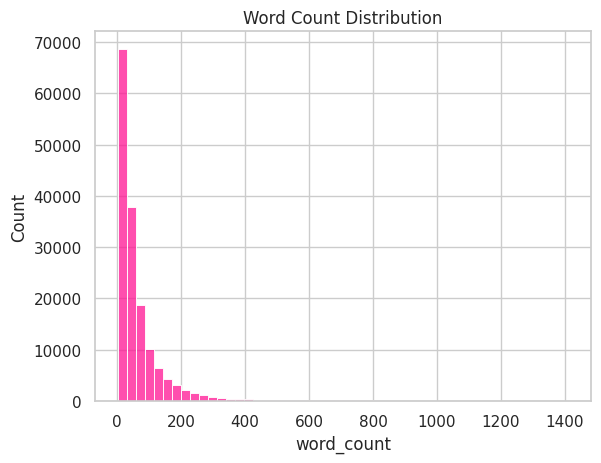

In [34]:
sns.histplot(df['word_count'], bins=50, color='deeppink')
plt.title("Word Count Distribution")
plt.show()

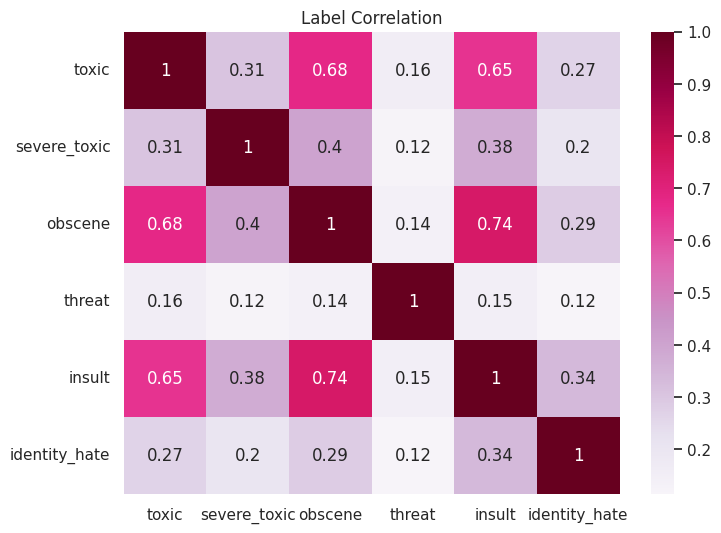

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(df[LABELS].corr(), annot=True, cmap='PuRd')
plt.title("Label Correlation")
plt.show()

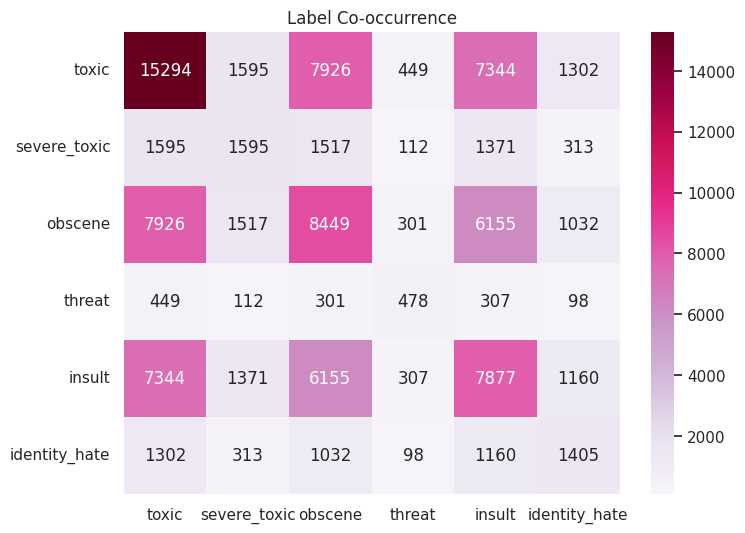

In [36]:
co_matrix = df[LABELS].T.dot(df[LABELS])

plt.figure(figsize=(8,6))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='PuRd')
plt.title("Label Co-occurrence")
plt.show()
# There is a strong correlation between: toxic and obscen & toxic and insult

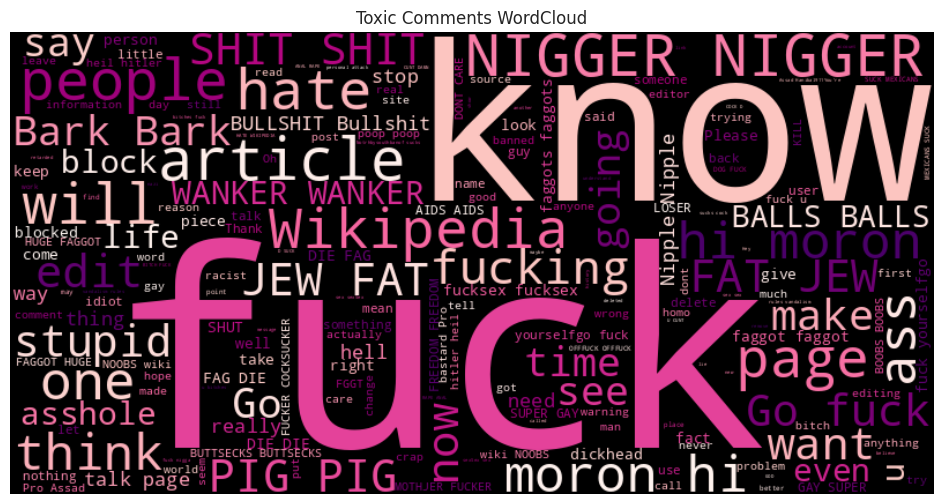

In [37]:
from wordcloud import WordCloud

toxic_text = " ".join(df[df['is_toxic']==1]['comment_text'].astype(str))

wc = WordCloud(width=800, height=400, background_color='black', colormap='RdPu').generate(toxic_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Toxic Comments WordCloud")
plt.show()

In [38]:
print("Class distribution (percent):")
(label_counts / len(df) * 100).round(2)
#"toxic" is the most frequent label, "threat" is extremely rare

Class distribution (percent):


toxic            9.58
obscene          5.29
insult           4.94
severe_toxic     1.00
identity_hate    0.88
threat           0.30
dtype: float64

In [39]:
multi_label_ratio = (df['num_labels'] > 1).mean()
print("Multi-label ratio:", multi_label_ratio)
#  the problem is multi-label classification

Multi-label ratio: 0.06182201026502309


In [40]:
df.groupby('is_toxic')['comment_length'].mean()
# Toxic comments tend to differ in length compared to clean comments.

is_toxic
0    404.347174
1    303.304037
Name: comment_length, dtype: float64

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df[df['is_toxic']==1]['comment_text'])

word_freq = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values(by='count', ascending=False)

word_freq

,word,count
6,fuck,9999
19,wikipedia,3931
12,like,3807
17,shit,3693
7,fucking,3337
14,nigger,3306
18,suck,3249
0,ass,3003
3,don,2846
10,just,2746


In [42]:
print(df[['comment_length', 'word_count']].describe())

       comment_length     word_count
count   159571.000000  159571.000000
mean       394.073221      67.273527
std        590.720282      99.230702
min          6.000000       1.000000
25%         96.000000      17.000000
50%        205.000000      36.000000
75%        435.000000      75.000000
max       5000.000000    1411.000000


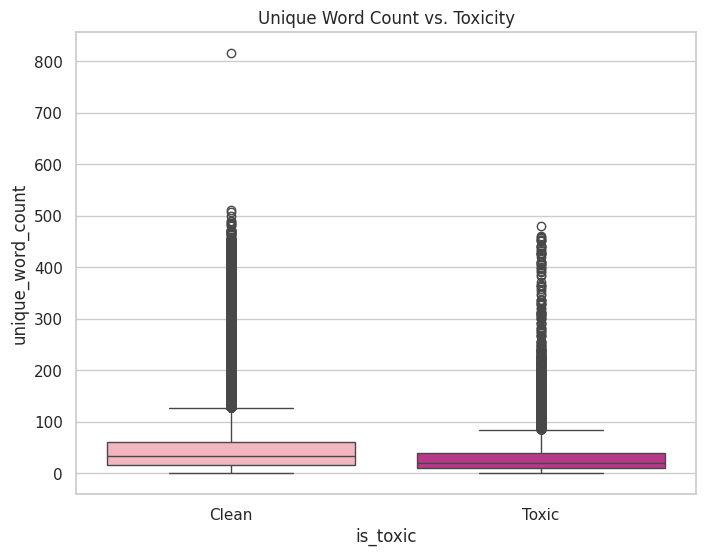

In [43]:
df['unique_word_count'] = df['comment_text'].astype(str).apply(lambda x: len(set(x.split())))

plt.figure(figsize=(8,6))
sns.boxplot(x='is_toxic', y='unique_word_count', data=df, hue='is_toxic', palette="RdPu", legend=False)
plt.xticks([0,1], ['Clean','Toxic'])
plt.title("Unique Word Count vs. Toxicity")
plt.show()

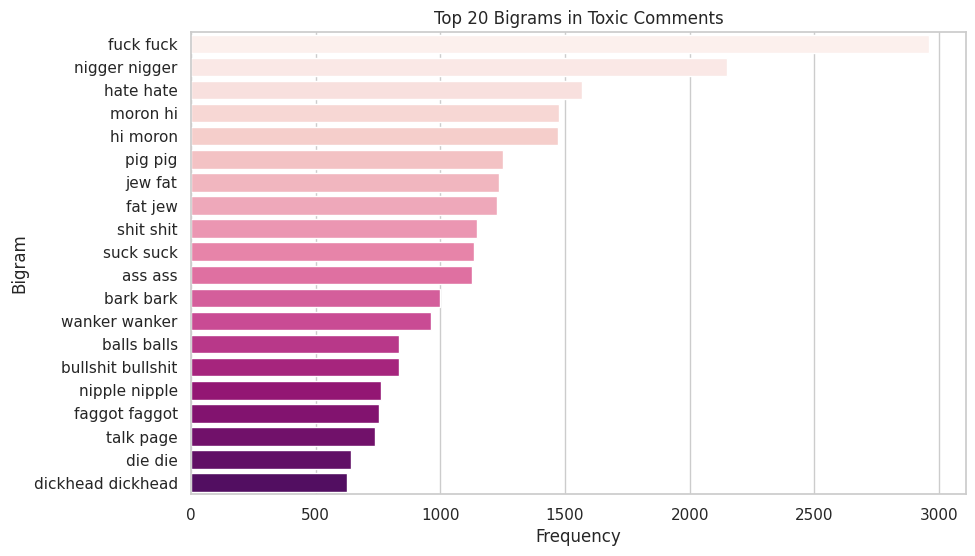

In [44]:
from sklearn.feature_extraction.text import CountVectorizer

toxic_df = df[df['is_toxic'] == 1]

# Bigrams
vectorizer_bigram = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=20)
X_bigram = vectorizer_bigram.fit_transform(toxic_df['comment_text'])

bigram_freq = pd.DataFrame({
    'bigram': vectorizer_bigram.get_feature_names_out(),
    'count': X_bigram.toarray().sum(axis=0)
}).sort_values(by='count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='bigram', data=bigram_freq, hue='bigram', palette='RdPu', legend=False)
plt.title("Top 20 Bigrams in Toxic Comments")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

# Final EDA Conclusions

1. The dataset is highly imbalanced, with rare classes like "threat".
2. The problem is multi-label, requiring specialized modeling approaches.
3. Certain labels are strongly correlated (e.g., toxic and obscene).
4. Text length and word usage provide useful predictive signals.
5. Toxic vocabulary is repetitive.